In [4]:
# ============================================================
# Cell 0 — Cài đặt thư viện
# ============================================================
!pip install -q seqeval
!pip uninstall -y torchcrf pytorch-crf 2>/dev/null || true
!pip install -q pytorch-crf

# ---- Tat HTTP INFO spam tu httpx / huggingface_hub ---- #
import logging as _logging
for _noisy in ("httpx", "huggingface_hub", "urllib3", "filelock"):
    _logging.getLogger(_noisy).setLevel(_logging.WARNING)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [7]:
# ============================================================
# Cell 1 — Reproducibility + Data Utilities
# ============================================================
import re, os, random, logging
from typing import List, Dict
from collections import Counter

import numpy as np
import torch

# ---- Seed ------------------------------------------------------------------ #
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# ---- Logger ---------------------------------------------------------------- #
logging.basicConfig(
    format="%(asctime)s %(levelname)s %(message)s",
    datefmt="%H:%M:%S",
    level=logging.INFO,
)
log = logging.getLogger(__name__)

# ============================================================
# parse_vlsp_file — doc file VLSP 5 cot (tab / space)
# ============================================================
def parse_vlsp_file(file_path: str) -> List[Dict]:
    sentences, current, inside_s = [], _empty_sent(), False

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            stripped = line.strip()

            if stripped == "<s>":
                inside_s, current = True, _empty_sent()
                continue
            if stripped == "</s>":
                inside_s = False
                if current["tokens"]:
                    sentences.append(current)
                continue
            if (
                not inside_s
                or stripped == ""
                or stripped.startswith("-DOCSTART-")
                or stripped.startswith("<")
            ):
                continue

            parts = line.split("\t") if "\t" in line else stripped.split()
            if len(parts) < 4:
                continue

            current["tokens"].append(parts[0])
            current["pos"].append(parts[1])
            current["chunks"].append(parts[2])
            current["labels"].append(parts[3])
            current["nested"].append(parts[4] if len(parts) > 4 else "O")

    log.info(f"Doc xong '{file_path}': {len(sentences)} cau")
    return sentences

def _empty_sent():
    return {"tokens": [], "pos": [], "chunks": [], "labels": [], "nested": []}


# ============================================================
# normalize_bio — chuan hoa BIO (fix I- khong co B- truoc)
#
# [BUG FIX] Ban goc bi THIEU phan elif I- va else
# => Cac label I- sai khong duoc sua => model hoc sai label
# ============================================================
VALID_TYPES = {"PER", "LOC", "ORG", "MISC"}

def normalize_bio(sentences: List[Dict]) -> List[Dict]:
    for sent in sentences:
        prev = None
        for i, lbl in enumerate(sent["labels"]):
            if lbl == "O":
                prev = None
            elif lbl.startswith("B-"):
                t = lbl[2:]
                if t not in VALID_TYPES:
                    sent["labels"][i], prev = "O", None
                else:
                    prev = t
            elif lbl.startswith("I-"):
                t = lbl[2:]
                if t not in VALID_TYPES or t != prev:
                    # Fix: I- khong co B- truoc -> chuyen thanh B- hoac O
                    sent["labels"][i] = f"B-{t}" if t in VALID_TYPES else "O"
                    prev = t if t in VALID_TYPES else None
            else:
                sent["labels"][i], prev = "O", None
    return sentences


# ============================================================
# check_label_distribution — phat hien som "all-O" problem
# [NEW] Goi ham nay ngay sau load_folder() de debug data
# ============================================================
def check_label_distribution(sentences: List[Dict], name: str = "dataset"):
    counter = Counter()
    for s in sentences:
        counter.update(s["labels"])
    total = sum(counter.values())
    o_pct = counter["O"] / total * 100 if total > 0 else 0
    entity_total = total - counter["O"]
    log.info(
        f"[{name}] {len(sentences)} cau | {total} tokens | "
        f"O={counter['O']}({o_pct:.1f}%) | entity_tokens={entity_total}"
    )
    if entity_total == 0:
        log.warning(
            f"WARNING [{name}]: KHONG CO ENTITY NAO! "
            "Kiem tra lai cot label (co the dang doc sai cot)"
        )
    non_o = {k: v for k, v in counter.most_common() if k != "O"}
    log.info(f"[{name}] Entity labels: {non_o}")
    return counter


# ============================================================
# Vocab helpers
# ============================================================
def build_label_vocab(sentences: List[Dict]):
    label2id = {"O": 0}
    for s in sentences:
        for lbl in s["labels"]:
            if lbl not in label2id:
                label2id[lbl] = len(label2id)
    return label2id, {v: k for k, v in label2id.items()}


def load_folder(folder_path):
    from pathlib import Path
    folder_path = Path(folder_path)
    sents = []
    for fp in sorted(folder_path.glob("*.txt")):
        sents.extend(parse_vlsp_file(str(fp)))
    return normalize_bio(sents)


def split_train_dev(sentences: List[Dict], dev_ratio=0.1, seed=42):
    idxs = list(range(len(sentences)))
    rng  = random.Random(seed)
    rng.shuffle(idxs)
    n_dev   = max(1, int(len(idxs) * dev_ratio))
    dev_set = set(idxs[:n_dev])
    return (
        [s for i, s in enumerate(sentences) if i not in dev_set],
        [s for i, s in enumerate(sentences) if i in dev_set],
    )

log.info("Cell 1 OK")


In [8]:
# ============================================================
# Cell 2 — VLSPDatasetPhoBERT
# ============================================================
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset


class VLSPDatasetPhoBERT(Dataset):

    def __init__(
        self,
        sentences: list,
        label2id: dict,
        model_name: str = "vinai/phobert-base",
        max_len: int = 256,
    ):
        self.data = sentences
        self.label2id = label2id
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        self.max_len = max_len
        self.cls_id = self.tokenizer.cls_token_id
        self.sep_id = self.tokenizer.sep_token_id
        self.pad_id = self.tokenizer.pad_token_id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sent   = self.data[idx]
        tokens = sent["tokens"]
        labels = sent["labels"]

        # PhoBERT dung dau '_' cho tu ghep -> normalize ve dau cach
        norm_tokens = [t.replace("_", " ") for t in tokens]

        # --- Tokenize tung word -> subword, build label sequence --- #
        subtoken_ids: List[int] = []
        label_ids: List[int]   = []

        for word_idx, word in enumerate(norm_tokens):
            wtoks = self.tokenizer.tokenize(word)
            if not wtoks:
                wtoks = [self.tokenizer.unk_token]
            wids = self.tokenizer.convert_tokens_to_ids(wtoks)
            subtoken_ids.extend(wids)
            # Token dau: label thuc; cac subword sau: -100
            label_ids.append(self.label2id.get(labels[word_idx], 0))
            label_ids.extend([-100] * (len(wids) - 1))

        # --- Truncate (chua cho cho CLS + SEP) --- #
        max_body = self.max_len - 2
        subtoken_ids = subtoken_ids[:max_body]
        label_ids    = label_ids[:max_body]

        # --- Ghep special tokens --- #
        input_ids  = [self.cls_id] + subtoken_ids + [self.sep_id]
        label_ids  = [-100]        + label_ids    + [-100]
        attn_mask  = [1] * len(input_ids)

        # --- Padding --- #
        pad_len    = self.max_len - len(input_ids)
        input_ids  += [self.pad_id] * pad_len
        attn_mask  += [0] * pad_len
        label_ids  += [-100] * pad_len

        assert len(input_ids) == self.max_len
        assert len(label_ids) == self.max_len

        return {
            "input_ids":      torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attn_mask,  dtype=torch.long),
            "labels":         torch.tensor(label_ids,  dtype=torch.long),
        }

log.info("Cell 2 OK")


In [9]:
# ============================================================
# Cell 3 — PhoBERTCRF Model
# ============================================================
import torch
import torch.nn as nn
from transformers import AutoModel
from torchcrf import CRF


class PhoBERTCRF(nn.Module):

    def __init__(
        self,
        num_labels: int,
        model_name: str = "vinai/phobert-base",
        dropout: float = 0.1,
        use_crf: bool = True,
        freeze_layers: int = 0,
    ):
        super().__init__()
        self.use_crf = use_crf
        self.bert = AutoModel.from_pretrained(model_name)
        H = self.bert.config.hidden_size  # 768 (base) | 1024 (large)

        if freeze_layers > 0:
            for p in self.bert.embeddings.parameters():
                p.requires_grad = False
            for i in range(freeze_layers):
                for p in self.bert.encoder.layer[i].parameters():
                    p.requires_grad = False

        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(H)
        self.classifier = nn.Linear(H, num_labels)

        if use_crf:
            self.crf = CRF(num_labels, batch_first=True)

        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.constant_(self.classifier.bias, 0.0)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: torch.Tensor = None,
    ):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        seq    = self.dropout(self.layer_norm(out.last_hidden_state))
        logits = self.classifier(seq)
        mask   = attention_mask.bool()

        if self.use_crf:
            if labels is not None:
                # CRF khong hieu -100 -> thay bang 0 truoc khi dua vao CRF
                safe_labels = labels.clone()
                safe_labels[safe_labels == -100] = 0
                loss  = -self.crf(logits, safe_labels, mask=mask, reduction="mean")
                preds = self.crf.decode(logits, mask=mask)
                return loss, preds
            preds = self.crf.decode(logits, mask=mask)
            return None, preds
        else:
            if labels is not None:
                loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
                loss    = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
                return loss, logits.argmax(-1)
            return None, logits.argmax(-1)

log.info("Cell 3 OK")


In [6]:
# ============================================================
# Cell 4 — NERTrainer
#
# [BUG FIX NGHIEM TRONG]: Cell nay bi THIEU HOAN TOAN trong notebook goc!
# NERTrainer chua duoc dinh nghia nen Cell 5 bi NameError khi chay.
#
# Cac fix khac trong evaluate():
#   - pred_ptr alignment dung cho CRF output (moi attn==1 deu tang pred_ptr)
#   - Guard chong seqeval crash khi khong co entity
#   - _save_checkpoint() save them label_mapping.json + config
# ============================================================
import os, json
from pathlib import Path

import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from seqeval.metrics import (
    classification_report, f1_score, precision_score, recall_score
)
from tqdm import tqdm


class NERTrainer:

    def __init__(
        self,
        model,
        train_loader,
        dev_loader,
        id2label: dict,
        bert_lr: float = 3e-5,
        cls_lr: float = 1e-3,
        epochs: int = 10,
        device: str = "cpu",
        out_dir: str = "checkpoints/phobert_crf",
        grad_clip: float = 1.0,
        warmup_pct: float = 0.1,
    ):
        self.model        = model.to(device)
        self.train_loader = train_loader
        self.dev_loader   = dev_loader
        self.id2label     = id2label
        self.epochs       = epochs
        self.device       = device
        self.out_dir      = Path(out_dir)
        self.grad_clip    = grad_clip
        self.out_dir.mkdir(parents=True, exist_ok=True)

        # Tach BERT params va classifier/CRF params voi learning rate khac nhau
        bert_params = list(model.bert.parameters())
        bert_param_ids = {id(p) for p in bert_params}
        other_params = [p for p in model.parameters() if id(p) not in bert_param_ids]

        self.optimizer = AdamW([
            {"params": bert_params,  "lr": bert_lr,  "weight_decay": 0.01},
            {"params": other_params, "lr": cls_lr,   "weight_decay": 0.0},
        ])

        total_steps = len(train_loader) * epochs
        self.scheduler = OneCycleLR(
            self.optimizer,
            max_lr=[bert_lr, cls_lr],
            total_steps=total_steps,
            pct_start=warmup_pct,
            anneal_strategy="cos",
        )

        self.best_f1  = -1.0
        self.history  = {"loss": [], "f1": [], "p": [], "r": []}

    # ------------------------------------------------------------------ #
    # TRAINING LOOP
    # ------------------------------------------------------------------ #
    def train(self):
        for epoch in range(1, self.epochs + 1):
            self.model.train()
            total_loss, steps = 0.0, 0

            pbar = tqdm(self.train_loader, desc=f"Epoch {epoch}/{self.epochs}", leave=True, position=0, dynamic_ncols=True)
            for batch in pbar:
                input_ids      = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels         = batch["labels"].to(self.device)

                self.optimizer.zero_grad()
                loss, _ = self.model(input_ids, attention_mask, labels)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                self.optimizer.step()
                self.scheduler.step()

                total_loss += loss.item()
                steps += 1
                pbar.set_postfix(loss=f"{loss.item():.4f}")

            avg_loss = total_loss / steps
            metrics  = self.evaluate(self.dev_loader)

            log.info(
                f"Epoch {epoch:02d} | loss={avg_loss:.4f} | "
                f"F1={metrics['f1']:.4f} P={metrics['p']:.4f} R={metrics['r']:.4f}"
            )

            self.history["loss"].append(avg_loss)
            self.history["f1"].append(metrics["f1"])
            self.history["p"].append(metrics["p"])
            self.history["r"].append(metrics["r"])

            if metrics["f1"] > self.best_f1:
                self.best_f1 = metrics["f1"]
                self._save_checkpoint(epoch, metrics)

        log.info(f"Training done. Best Dev F1 = {self.best_f1:.4f}")
        return self.history

    # ------------------------------------------------------------------ #
    # EVALUATE
    # ------------------------------------------------------------------ #
    def evaluate(self, loader) -> dict:
        self.model.eval()
        true_labels, pred_labels = [], []

        with torch.no_grad():
            for batch in loader:
                input_ids      = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels_np      = batch["labels"].numpy()
                attn_cpu       = batch["attention_mask"].numpy()

                _, preds = self.model(input_ids, attention_mask, labels=None)
                # preds: List[List[int]], do dai moi sample = so token co attention=1

                for i in range(len(labels_np)):
                    true_seq, pred_seq = [], []
                    pred_ptr = 0  # index vao preds[i]

                    for j in range(len(labels_np[i])):
                        attn_j = int(attn_cpu[i][j])
                        lbl_j  = int(labels_np[i][j])

                        if attn_j == 1:
                            if lbl_j != -100:
                                # Token dau cua mot word thuc -> ghi nhan
                                true_seq.append(self.id2label[lbl_j])
                                pred_seq.append(self.id2label[preds[i][pred_ptr]])
                            # [BUG FIX] Tang pred_ptr cho MOI vi tri attention=1
                            # (ca subword), vi CRF decode cho tat ca non-pad tokens
                            pred_ptr += 1
                        # attn_j == 0: padding -> CRF khong decode -> khong tang ptr

                    true_labels.append(true_seq)
                    pred_labels.append(pred_seq)

        # Guard: seqeval crash neu khong co entity
        flat_true = [l for seq in true_labels for l in seq]
        flat_pred = [l for seq in pred_labels for l in seq]
        has_true  = any(l != "O" for l in flat_true)
        has_pred  = any(l != "O" for l in flat_pred)

        if not has_true:
            log.warning("EVALUATE: true_labels toan O -> khong co entity trong tap nay.")
        if not has_pred:
            log.warning("EVALUATE: pred_labels toan O -> model bi collapse hoac data sai.")

        if has_true and has_pred:
            f1  = f1_score(true_labels, pred_labels, zero_division=0)
            p   = precision_score(true_labels, pred_labels, zero_division=0)
            r   = recall_score(true_labels, pred_labels, zero_division=0)
            rep = classification_report(true_labels, pred_labels, digits=4, zero_division=0)
        else:
            f1 = p = r = 0.0
            rep = "[SKIP] Khong co entity trong true hoac pred labels."

        # Debug 3 cau dau
        for dbg_i in range(min(3, len(true_labels))):
            log.info(f"[DEBUG] Cau {dbg_i} True: {true_labels[dbg_i][:15]}")
            log.info(f"[DEBUG] Cau {dbg_i} Pred: {pred_labels[dbg_i][:15]}")

        return {"f1": f1, "p": p, "r": r, "report": rep,
                "true": true_labels, "pred": pred_labels}

    # ------------------------------------------------------------------ #
    # SAVE CHECKPOINT
    # [BUG FIX] Ban goc chi save state_dict, THIEU tokenizer + label mapping
    # ------------------------------------------------------------------ #
    def _save_checkpoint(self, epoch: int, metrics: dict):
        # 1. Model weights
        torch.save(self.model.state_dict(), self.out_dir / "best_model.pt")

        # 2. Label mapping — bat buoc de load lai dung
        id2label_str = {str(k): v for k, v in self.id2label.items()}
        label2id_str = {v: int(k) for k, v in id2label_str.items()}
        with open(self.out_dir / "label_mapping.json", "w", encoding="utf-8") as f:
            json.dump({"id2label": id2label_str, "label2id": label2id_str},
                      f, ensure_ascii=False, indent=2)

        # 3. Training config
        cfg_to_save = {"epoch": epoch, "f1": metrics["f1"],
                       "p": metrics["p"], "r": metrics["r"]}
        with open(self.out_dir / "best_config.json", "w") as f:
            json.dump(cfg_to_save, f, indent=2)

        log.info(
            f"Checkpoint saved (epoch={epoch}, F1={metrics['f1']:.4f}) -> {self.out_dir}"
        )

log.info("Cell 4 (NERTrainer) OK")


01:01:59 INFO Cell 4 (NERTrainer) OK


01:02:04 INFO Device: cuda
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/100276.txt': 53 cau
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/100448.txt': 59 cau
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/100824.txt': 30 cau
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/100923.txt': 119 cau
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/100970.txt': 40 cau
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/101574.txt': 65 cau
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/102388.txt': 57 cau
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/102770.txt': 59 cau
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/102794.txt': 71 cau
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/102870.txt': 91 cau
01:02:04 INFO Doc xong '/kaggle/input/datasets/khuynhongvn/ner-train/102984.txt': 

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
01:02:13 INFO Model params: 135,006,828
Epoch 1/10: 100%|██████████| 843/843 [13:34<00:00,  1.04it/s, loss=1.6410] 
01:16:13 INFO [DEBUG] Cau 0 True: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
01:16:13 INFO [DEBUG] Cau 0 Pred: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'


Test | F1=0.9459  P=0.9438  R=0.9479

              precision    recall  f1-score   support

         LOC     0.9365    0.9502    0.9433       683
        MISC     0.9630    0.9630    0.9630        27
         ORG     0.7391    0.7727    0.7556       110
         PER     0.9804    0.9703    0.9753       774

   micro avg     0.9438    0.9479    0.9459      1594
   macro avg     0.9048    0.9140    0.9093      1594
weighted avg     0.9447    0.9479    0.9462      1594



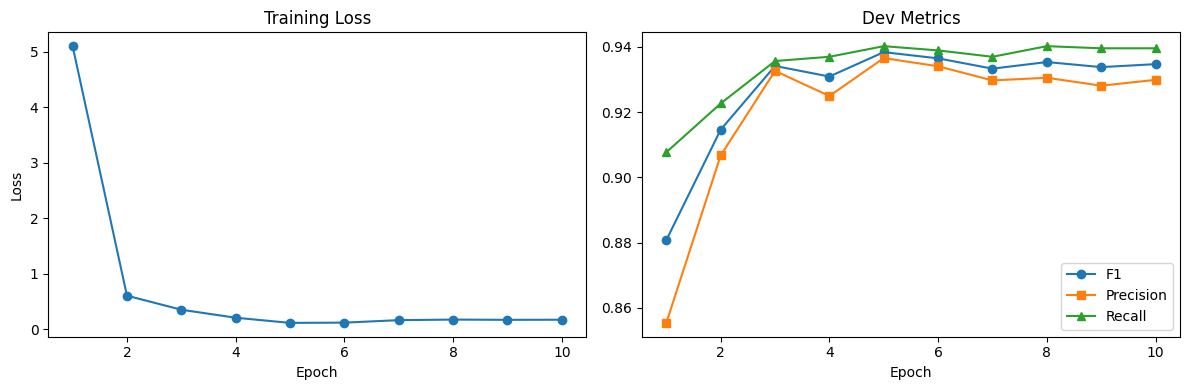

In [7]:
# ============================================================
# Cell 5 — Main: Load data -> Build vocab -> Train -> Evaluate
# ============================================================
from pathlib import Path
from torch.utils.data import DataLoader

# ---- Config ---------------------------------------------------------------- #
CFG = {
    "phobert_name": "vinai/phobert-base",
    "max_len":      256,
    "batch_size":   16,
    "epochs":       10,
    "bert_lr":      3e-5,
    "cls_lr":       1e-3,
    "dropout":      0.1,
    "use_crf":      True,
    "freeze_layers": 0,
    "device":       "cuda" if torch.cuda.is_available() else "cpu",
    "out_dir":      "checkpoints/phobert_crf",
    "num_workers":  0,
    "pin_memory":   True,
}
log.info(f"Device: {CFG['device']}")

# ---- Paths (Kaggle) -------------------------------------------------------- #
TRAIN_PATH = Path("/kaggle/input/datasets/khuynhongvn/ner-train")
# [CHANGED] Khong dung thu muc ner-test rieng biet nua.
# Tu chia train_all thanh 80% train / 10% dev / 10% test (seed co dinh de tái lập).

# ---- Load & split (80 / 10 / 10) ----------------------------------------- #
train_all = load_folder(TRAIN_PATH)

# Buoc 1: tach 10% lam test truoc
_rng_test = __import__("random").Random(SEED)
_idxs = list(range(len(train_all)))
_rng_test.shuffle(_idxs)
_n_test   = max(1, int(len(_idxs) * 0.10))
_test_set = set(_idxs[:_n_test])
_traindev = [s for i, s in enumerate(train_all) if i not in _test_set]
test       = [s for i, s in enumerate(train_all) if i in     _test_set]

# Buoc 2: tach 10% cua phan con lai lam dev (~ 10% tong the)
train, dev = split_train_dev(_traindev, dev_ratio=0.111, seed=SEED)
# dev_ratio=0.111 * 90% ~ 10% tong the => train~80%, dev~10%, test~10%

log.info(f"Tong: {len(train_all)} | Train: {len(train)} | Dev: {len(dev)} | Test: {len(test)}")

# [NEW] Kiem tra phan phoi label TRUOC KHI TRAIN
# Neu entity_total == 0 -> dung lai, kiem tra lai data
check_label_distribution(train, "TRAIN")
check_label_distribution(dev,   "DEV")
check_label_distribution(test,  "TEST")

# ---- Build vocab tu TRAIN (khong dung train_all de clean hon) -------------- #
# [NOTE] Ban goc dung build_label_vocab(train_all) nhung dev la subset cua train_all
# => Dung train de build vocab la sach hon (label tu dev co the chua xuat hien trong train)
label2id, id2label = build_label_vocab(train)
log.info(f"Labels ({len(label2id)}): {label2id}")

# ---- Dataset --------------------------------------------------------------- #
TrainDS = VLSPDatasetPhoBERT(train, label2id, CFG["phobert_name"], CFG["max_len"])
DevDS   = VLSPDatasetPhoBERT(dev,   label2id, CFG["phobert_name"], CFG["max_len"])
TestDS  = VLSPDatasetPhoBERT(test,  label2id, CFG["phobert_name"], CFG["max_len"])

# ---- DataLoader ------------------------------------------------------------ #
train_loader = DataLoader(
    TrainDS, batch_size=CFG["batch_size"], shuffle=True,
    num_workers=CFG["num_workers"], pin_memory=CFG["pin_memory"],
)
dev_loader = DataLoader(
    DevDS, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=CFG["pin_memory"],
)
test_loader = DataLoader(
    TestDS, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=CFG["pin_memory"],
)

# ---- Model ----------------------------------------------------------------- #
model = PhoBERTCRF(
    num_labels    = len(label2id),
    model_name    = CFG["phobert_name"],
    dropout       = CFG["dropout"],
    use_crf       = CFG["use_crf"],
    freeze_layers = CFG["freeze_layers"],
)
log.info(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

# ---- Train ----------------------------------------------------------------- #
trainer = NERTrainer(
    model        = model,
    train_loader = train_loader,
    dev_loader   = dev_loader,
    id2label     = id2label,
    bert_lr      = CFG["bert_lr"],
    cls_lr       = CFG["cls_lr"],
    epochs       = CFG["epochs"],
    device       = CFG["device"],
    out_dir      = CFG["out_dir"],
)
history = trainer.train()

# ---- Test evaluation ------------------------------------------------------- #
log.info("\n=== Test Set Evaluation ===")
model.load_state_dict(
    torch.load(
        f"{CFG['out_dir']}/best_model.pt",
        map_location=CFG["device"],
        weights_only=True,
    )
)
m = trainer.evaluate(test_loader)
print(f"\nTest | F1={m['f1']:.4f}  P={m['p']:.4f}  R={m['r']:.4f}")
print("\n" + m["report"])

# ---- Plot training curve --------------------------------------------------- #
try:
    import matplotlib.pyplot as plt
    epochs_range = range(1, len(history["loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs_range, history["loss"], marker="o")
    ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax2.plot(epochs_range, history["f1"],  marker="o", label="F1")
    ax2.plot(epochs_range, history["p"],   marker="s", label="Precision")
    ax2.plot(epochs_range, history["r"],   marker="^", label="Recall")
    ax2.set_title("Dev Metrics"); ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout(); plt.show()
except ImportError:
    pass


In [11]:
# ============================================================
# Cell 6 — Standalone Evaluate (chay doc lap, khong can train lai)
# ============================================================
import torch, json
from pathlib import Path
from torch.utils.data import DataLoader
from seqeval.metrics import classification_report
from tqdm import tqdm

# ==========================================
# 1. CAU HINH
# ==========================================
MODEL_PATH = "/kaggle/input/models/khuynhongvn/dl-final2/pytorch/default/1/checkpoints/phobert_crf/best_model.pt"
TRAIN_DIR  = "/kaggle/input/datasets/khuynhongvn/ner-train"
# [CHANGED] Khong dung thu muc ner-test rieng biet nua; test duoc lay tu split 80/10/10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Su dung thiet bi: {device}")

# ==========================================
# 2. KHOI PHUC VOCAB
# [BUG FIX] Uu tien load tu label_mapping.json neu co
# Dam bao label2id DONG NHAT voi luc train
# ==========================================
label_map_path = Path(MODEL_PATH).parent / "label_mapping.json"
if label_map_path.exists():
    with open(label_map_path, "r") as f:
        maps = json.load(f)
    label2id = {k: int(v) for k, v in maps["label2id"].items()}
    id2label = {int(k): v for k, v in maps["id2label"].items()}
    print(f"Loaded label mapping tu file: {len(label2id)} labels")
else:
    print("CANH BAO: Khong tim thay label_mapping.json, build lai tu train data...")
    # [CHANGED] Dung cung logic split 80/10/10 nhu Cell 5
    _all = load_folder(TRAIN_DIR)
    _rng_t = __import__("random").Random(SEED)
    _idx2 = list(range(len(_all))); _rng_t.shuffle(_idx2)
    _n_t2 = max(1, int(len(_idx2) * 0.10))
    _tset2 = set(_idx2[:_n_t2])
    _td2 = [s for i, s in enumerate(_all) if i not in _tset2]
    _trainonly2, _ = split_train_dev(_td2, dev_ratio=0.111, seed=SEED)
    label2id, id2label = build_label_vocab(_trainonly2)
    print("De tranh bug nay lan sau: NERTrainer._save_checkpoint() da duoc fix de save label_mapping.json")

print(f"So luong labels: {len(label2id)} | Labels: {list(label2id.keys())}")

# ==========================================
# 3. KHOI TAO MODEL & LOAD TRONG SO
# ==========================================
model = PhoBERTCRF(
    num_labels=len(label2id),
    model_name="vinai/phobert-base",
    use_crf=True,
    freeze_layers=0
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device)
model.eval()
print("Da load model thanh cong!")

# ==========================================
# 4. CHUAN BI TAP DU LIEU TEST
# ==========================================
# [CHANGED] Tai lai test set tu split 80/10/10 (cung seed nhu luc train)
_all_c6 = load_folder(TRAIN_DIR)
_rng_c6 = __import__("random").Random(SEED)
_idxs_c6 = list(range(len(_all_c6))); _rng_c6.shuffle(_idxs_c6)
_n_test_c6 = max(1, int(len(_idxs_c6) * 0.10))
test_data = [s for i, s in enumerate(_all_c6) if i in set(_idxs_c6[:_n_test_c6])]
check_label_distribution(test_data, "TEST")  # Kiem tra phan phoi truoc

test_ds = VLSPDatasetPhoBERT(test_data, label2id, "vinai/phobert-base", max_len=256)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# ==========================================
# 5. DANH GIA
# [BUG FIX] Sua pred_ptr alignment: moi attn==1 deu tang pred_ptr
# (ban goc chi tang o elif branch, bo sot khi attn==1 va label!=-100)
# ==========================================
true_labels, pred_labels = [], []

print("Dang tien hanh danh gia tap Test...")
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_np      = batch["labels"].numpy()
        attn_cpu       = batch["attention_mask"].numpy()

        _, preds = model(input_ids=input_ids, attention_mask=attention_mask, labels=None)

        for i in range(len(labels_np)):
            true_seq, pred_seq = [], []
            pred_ptr = 0

            for j in range(len(labels_np[i])):
                attn_j = int(attn_cpu[i][j])
                lbl_j  = int(labels_np[i][j])

                if attn_j == 1:
                    if lbl_j != -100:
                        true_seq.append(id2label[lbl_j])
                        pred_seq.append(id2label[preds[i][pred_ptr]])
                    # Tang pred_ptr cho MOI vi tri attention=1 (ca subword)
                    pred_ptr += 1
                # attn_j == 0: padding -> khong tang pred_ptr

            true_labels.append(true_seq)
            pred_labels.append(pred_seq)

# ==========================================
# 6. IN BAO CAO
# ==========================================
print("\n=== KET QUA DANH GIA TREN TAP TEST ===")

flat_true = [l for seq in true_labels for l in seq]
flat_pred = [l for seq in pred_labels for l in seq]
has_true  = any(l != "O" for l in flat_true)
has_pred  = any(l != "O" for l in flat_pred)

if has_true and has_pred:
    print(classification_report(true_labels, pred_labels, digits=4, zero_division=0))
elif not has_true:
    print("CANH BAO: true_labels toan O!")
    print("-> Kha nang cao: tap test bi an nhan (hidden labels) tren Kaggle.")
    print("-> Neu dung vay: khong the dung seqeval. Xuat pred ra file de submit.")
elif not has_pred:
    print("CANH BAO: pred_labels toan O -> model collapse!")
    print("-> Kiem tra: (1) label_mapping co dung khong? (2) model train du chua?")
    print("-> Debug: in logits truc tiep de xem model co hoc duoc gi khong.")

# Debug 3 cau dau
print("\n[DEBUG] Ket qua 3 cau dau tien:")
for i in range(min(3, len(true_labels))):
    print(f"\nCau {i+1}:")
    print(f"  True: {true_labels[i]}")
    print(f"  Pred: {pred_labels[i]}")


Su dung thiet bi: cuda
Loaded label mapping tu file: 9 labels
So luong labels: 9 | Labels: ['O', 'B-LOC', 'B-ORG', 'I-LOC', 'B-PER', 'I-PER', 'I-ORG', 'B-MISC', 'I-MISC']


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dang tien hanh danh gia tap Test...


100%|██████████| 106/106 [00:22<00:00,  4.74it/s]



=== KET QUA DANH GIA TREN TAP TEST ===
              precision    recall  f1-score   support

         LOC     0.9365    0.9502    0.9433       683
        MISC     0.9630    0.9630    0.9630        27
         ORG     0.7391    0.7727    0.7556       110
         PER     0.9804    0.9703    0.9753       774

   micro avg     0.9438    0.9479    0.9459      1594
   macro avg     0.9048    0.9140    0.9093      1594
weighted avg     0.9447    0.9479    0.9462      1594


[DEBUG] Ket qua 3 cau dau tien:

Cau 1:
  True: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'B-LOC', 'I-LOC', 'O', 'B-LOC', 'I-LOC', 'O', 'B-LOC', 'O']
  Pred: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'B-LOC', 'I-LOC', 'O

In [2]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 56.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.7 MB/s eta 0:00:00


In [12]:
import torch
from transformers import AutoTokenizer
from underthesea import word_tokenize

MODEL_PATH = "/kaggle/input/models/khuynhongvn/dl-final2/pytorch/default/1/checkpoints/phobert_crf/best_model.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PhoBERTCRF(
    num_labels=len(label2id),
    model_name="vinai/phobert-base",
    use_crf=True
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")


def predict_text(text):

    # ===== 1. WORD SEGMENTATION =====
    words = word_tokenize(text, format="text").split()
    # ["Nguyễn_Văn_A", "đang", "học"]

    # ===== 2. BUILD INPUT GIỐNG DATASET =====
    subtoken_ids = []
    word_map = []  # map subtoken -> word index

    for i, word in enumerate(words):
        norm_word = word.replace("_", " ")
        tokens = tokenizer.tokenize(norm_word)

        if not tokens:
            tokens = [tokenizer.unk_token]

        ids = tokenizer.convert_tokens_to_ids(tokens)

        subtoken_ids.extend(ids)
        word_map.extend([i] * len(ids))  # map lại word index

    # truncate
    max_body = 256 - 2
    subtoken_ids = subtoken_ids[:max_body]
    word_map     = word_map[:max_body]

    # add special tokens
    input_ids = [tokenizer.cls_token_id] + subtoken_ids + [tokenizer.sep_token_id]
    attention_mask = [1] * len(input_ids)

    # padding
    pad_len = 256 - len(input_ids)
    input_ids += [tokenizer.pad_token_id] * pad_len
    attention_mask += [0] * pad_len

    input_ids = torch.tensor([input_ids]).to(device)
    attention_mask = torch.tensor([attention_mask]).to(device)

    # ===== 3. PREDICT =====
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    preds = outputs
    if isinstance(outputs, (tuple, list)):
        preds = outputs[1]

    if torch.is_tensor(preds):
        preds = preds[0].detach().cpu().numpy()
    else:
        preds = preds[0]

    # ===== 4. MAP SUBWORD -> WORD =====
    word_labels = ["O"] * len(words)
    used = set()

    for i, label_id in enumerate(preds[1:len(word_map)+1]):  # bỏ CLS

        word_idx = word_map[i]

        # chỉ lấy subword đầu tiên của mỗi word
        if word_idx in used:
            continue

        used.add(word_idx)

        label = id2label.get(str(int(label_id)), id2label.get(int(label_id), "O"))

        word_labels[word_idx] = label

    # ===== 5. FORMAT OUTPUT GIỐNG TRAIN =====
    results = list(zip(words, word_labels))

    return results






Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
# ===== TEST (INPUT TỪ USER) =====

while True:
    text = input("\nNhập câu cần NER (hoặc 'exit' để thoát): ")

    if text.lower() == "exit":
        break

    result = predict_text(text)

    print("\n=== KẾT QUẢ NER ===")
    for w, l in result:
        print(f"{w:15} -> {l}")


Nhập câu cần NER (hoặc 'exit' để thoát):  Vào lúc 8:30 ngày 15/05/2026, bà Anna Schmidt từ Google Cloud đã có buổi làm việc với Bộ Thông tin và Truyền thông tại Hà Nội. Hai bên thảo luận về việc rót thêm 1,2 tỷ USD vào dự án AI Hub đặt tại Khu công nghệ cao Hòa Lạc. Theo Nikkei Asia, chỉ số VN30 đã phản ứng tích cực sau tin này. Đồng thời, kỹ sư Trần Văn Nam của tập đoàn FPT cho biết doanh nghiệp sẽ cử 500 nhân sự sang Singapore để đào tạo chuyên sâu về Large Language Models.



=== KẾT QUẢ NER ===
Vào             -> O
lúc             -> O
8               -> O
:               -> O
30              -> O
ngày            -> O
15/05/2026      -> O
,               -> O
bà              -> O
Anna_Schmidt    -> B-PER
từ              -> O
Google_Cloud    -> B-ORG
đã              -> O
có              -> O
buổi            -> O
làm_việc        -> O
với             -> O
Bộ              -> B-ORG
Thông_tin       -> I-ORG
và              -> I-ORG
Truyền_thông    -> I-ORG
tại             -> O
Hà_Nội          -> B-LOC
.               -> O
Hai             -> O
bên             -> O
thảo_luận       -> O
về              -> O
việc            -> O
rót             -> O
thêm            -> O
1,2             -> O
tỷ              -> O
USD             -> O
vào             -> O
dự_án           -> O
AI              -> B-LOC
Hub             -> I-LOC
đặt             -> O
tại             -> O
Khu             -> B-LOC
công_nghệ_cao   -> O
Hòa_Lạc         -> I-LOC
.               -> O
Theo       

KeyboardInterrupt: Interrupted by user